In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df = df.dropna(subset=["CustomerID"])

In [6]:
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [7]:
returns = df[df["Quantity"] < 0]
df = df[df["Quantity"] > 0]

In [8]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [9]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
country_revenue

Country
United Kingdom          7308391.554
Netherlands              285446.340
EIRE                     265545.900
Germany                  228867.140
France                   209024.050
Australia                138521.310
Spain                     61577.110
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38378.330
Japan                     37416.370
Norway                    36165.440
Portugal                  33439.890
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20450.440
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13590.380
Austria                   10198.680
Poland                     7334.650
Israel                     7221.690
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

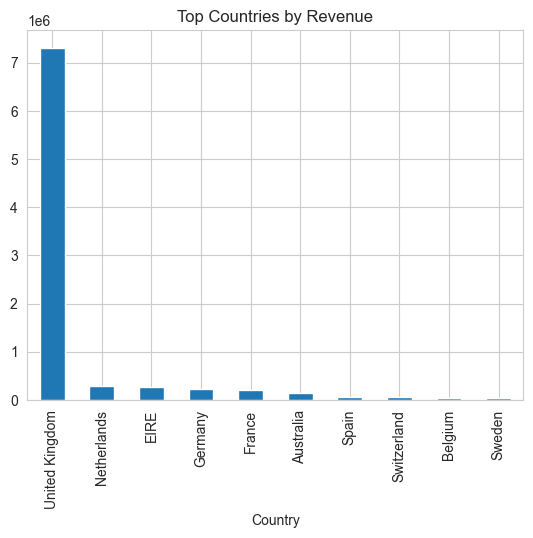

In [10]:
country_revenue.head(10).plot(kind="bar")
plt.title("Top Countries by Revenue")
plt.show()

In [11]:
customer_analysis = df.groupby("CustomerID").agg({"Revenue": "sum","InvoiceNo": "count","Quantity": "sum"})

In [12]:
customer_analysis["AOV"] = customer_analysis["Revenue"] / customer_analysis["InvoiceNo"]
customer_analysis.head()

,Revenue,InvoiceNo,Quantity,AOV
CustomerID,,,,
12346.0,77183.60,1,74215,77183.600000
12347.0,4310.00,182,2458,23.681319
12348.0,1797.24,31,2341,57.975484
12349.0,1757.55,73,631,24.076027
12350.0,334.40,17,197,19.670588


In [13]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.month

In [14]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue

Month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: Revenue, dtype: float64

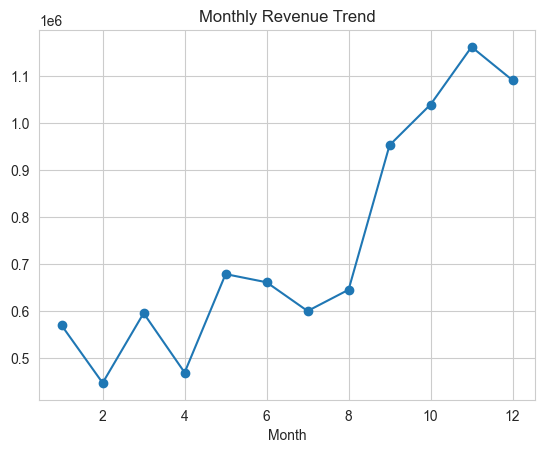

In [15]:
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.show()

In [16]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(20)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345
PACK OF 60 PINK PAISLEY CAKE CASES    24264
BROCADE RING PURSE                    22963
VICTORIAN GLASS HANGING T-LIGHT       22433
ASSORTED COLOURS SILK FAN             21876
RED  HARMONICA IN BOX                 20975
JUMBO BAG PINK POLKADOT               20165
SMALL POPCORN HOLDER                  18252
LUNCH BAG RED RETROSPOT               17697
60 TEATIME FAIRY CAKE CASES           17689
Name: Quantity, dtype: int64

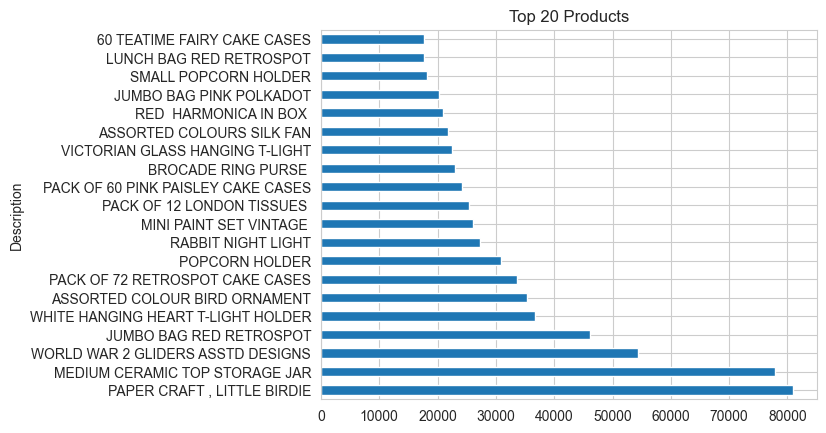

In [17]:
top_products.plot(kind="barh")
plt.title("Top 20 Products")
plt.show()

In [18]:
return_rate = len(returns) / len(df)
return_rate

0.0

In [19]:
return_country = returns.groupby("Country")["Quantity"].sum()
return_country

Series([], Name: Quantity, dtype: int64)

In [20]:
top_customers = customer_analysis.sort_values("Revenue", ascending=False).head(10)
top_customers

,Revenue,InvoiceNo,Quantity,AOV
CustomerID,,,,
14646.0,280206.02,2080,197491,134.714433
18102.0,259657.30,431,64124,602.453132
17450.0,194550.79,337,69993,577.302047
16446.0,168472.50,3,80997,56157.500000
14911.0,143825.06,5677,80515,25.334694
12415.0,124914.53,716,77670,174.461634
14156.0,117379.63,1400,57885,83.842593
17511.0,91062.38,963,64549,94.561142
16029.0,81024.84,242,40208,334.813388


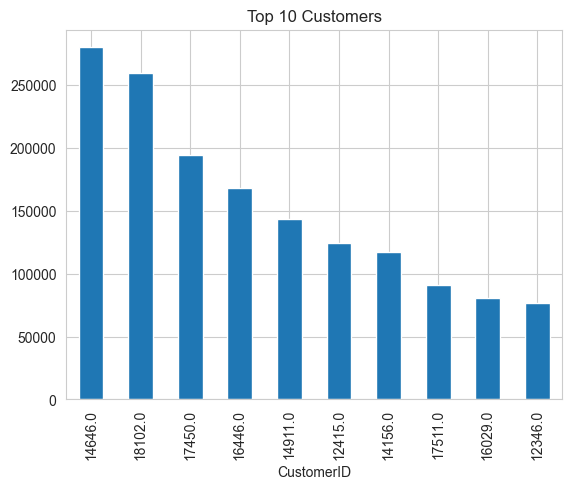

In [ ]:
top_customers["Revenue"].plot(kind="bar")
plt.title("Top 10 Customers")
plt.show() #bonus

In [22]:
basket_size = df.groupby(["Country", "InvoiceNo"])["StockCode"].nunique().reset_index()
basket_size

,Country,InvoiceNo,StockCode
0,Australia,536389,14
1,Australia,537676,8
2,Australia,539419,9
3,Australia,540267,46
4,Australia,540280,2
...,...,...,...
18531,Unspecified,559929,15
18532,Unspecified,561658,82
18533,Unspecified,561661,47
18534,Unspecified,563947,7


In [ ]:
basket_size = df.groupby(["Country", "InvoiceNo"])["StockCode"].nunique().reset_index()
basket_size #bonus

,Country,InvoiceNo,StockCode
0,Australia,536389,14
1,Australia,537676,8
2,Australia,539419,9
3,Australia,540267,46
4,Australia,540280,2
...,...,...,...
18531,Unspecified,559929,15
18532,Unspecified,561658,82
18533,Unspecified,561661,47
18534,Unspecified,563947,7
